# Pipeline: SAM3 Segmentation → Potrace Vectorization → DXF Export

الفكرة: بدل تتبّع السكيلتون (Zhang-Suen) وحواف Canny يدويًا، بعد ما نطلع القناع (mask)
من SAM3 هنمرره مباشرة لخوارزمية **Potrace** (نسخة Python نقية `potracer`) اللي بتحوّل
القناع الثنائي لمسارات متجهية حقيقية (خطوط مستقيمة + منحنيات Bezier)، وبعدين نحوّل المسارات
دي مباشرة لكيانات DXF (LWPOLYLINE / SPLINE) باستخدام `ezdxf`.

In [1]:
# Cell 1: Installation
!pip install -q torch torchvision
!pip install -q git+https://github.com/facebookresearch/segment-anything-2.git
!pip install -q ezdxf
!pip install -q potracer          # نسخة بايثون خالصة من Potrace (لا تحتاج build خارجي)
!pip install -q opencv-python-headless
!pip install -q numpy matplotlib Pillow requests
!pip install -q sam3
!pip install -q huggingface_hub
!pip install -q triton

print("Installation done!")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
Installation done!


In [39]:
import torch
import numpy as np
from transformers import CLIPProcessor, CLIPModel
from PIL import Image, ImageDraw

# تحميل الموديل
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# تحميل الصورة
image = Image.open("/content/th.webp").convert("RGB")
W, H = image.size

# النصوص (حط كذا prompt عشان مقارنة صح)
text = [
    "plane",
    "random object",
    "metal machine",
    "human face"
]

# إعدادات التقسيم
patch_size = 128
stride = 64

boxes = []
scores = []

# تقسيم الصورة (Sliding Window)
for y in range(0, H - patch_size, stride):
    for x in range(0, W - patch_size, stride):
        patch = image.crop((x, y, x + patch_size, y + patch_size))

        inputs = processor(
            text=text,
            images=patch,
            return_tensors="pt",
            padding=True
        )

        with torch.no_grad():
            outputs = model(**inputs)
            probs = outputs.logits_per_image.softmax(dim=1)

        score = probs[0][0].item()  # أول label

        if score > 0.3:  # threshold
            boxes.append([x, y, x + patch_size, y + patch_size])
            scores.append(score)

# لو مفيش حاجة اتلقطت
if len(boxes) == 0:
    raise RuntimeError("No object detected — جرّب تقلل الـ threshold أو تغيّر الـ prompts")

# دمج كل البوكسات في بوكس واحد كبير
x1 = min([b[0] for b in boxes])
y1 = min([b[1] for b in boxes])
x2 = max([b[2] for b in boxes])
y2 = max([b[3] for b in boxes])

final_box = [x1, y1, x2, y2]
print("Final box:", final_box)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Final box: [0, 0, 128, 128]


In [28]:
# ⚠️ لا تحط الـ Hugging Face token هنا كنص ثابت (Hardcoded) — ده ثغرة أمنية لو شاركت
# النوت بوك أو رفعتها على GitHub. استخدم أحد الطرق الآمنة دي بدلاً من ذلك:
#
#   الطريقة 1 (موصى بها في Colab): من القائمة الجانبية 🔑 Secrets، ضيف Secret اسمه HF_TOKEN
#   from google.colab import userdata
#   hf_token = userdata.get('HF_TOKEN')
#
#   الطريقة 2: إدخال يدوي مخفي (مش بيتسجل في الـ notebook)
#   from getpass import getpass
#   hf_token = getpass('HF token: ')

from huggingface_hub import login
from getpass import getpass

hf_token = getpass("HF token: ")
login(token=hf_token)
print("done")

HF token: ··········
done


In [40]:
import os
import sam3

os.makedirs("/usr/local/lib/python3.12/dist-packages/assets", exist_ok=True)

# تحميل الملف
!wget -q "https://github.com/openai/CLIP/raw/main/clip/bpe_simple_vocab_16e6.txt.gz" \
     -O "/usr/local/lib/python3.12/dist-packages/assets/bpe_simple_vocab_16e6.txt.gz"

# تحديد مسار الـ bpe file الصح
sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")
bpe_path = "/usr/local/lib/python3.12/dist-packages/assets/bpe_simple_vocab_16e6.txt.gz"

print("bpe path:", bpe_path)
print("موجود؟", os.path.exists(bpe_path))

bpe path: /usr/local/lib/python3.12/dist-packages/assets/bpe_simple_vocab_16e6.txt.gz
موجود؟ True


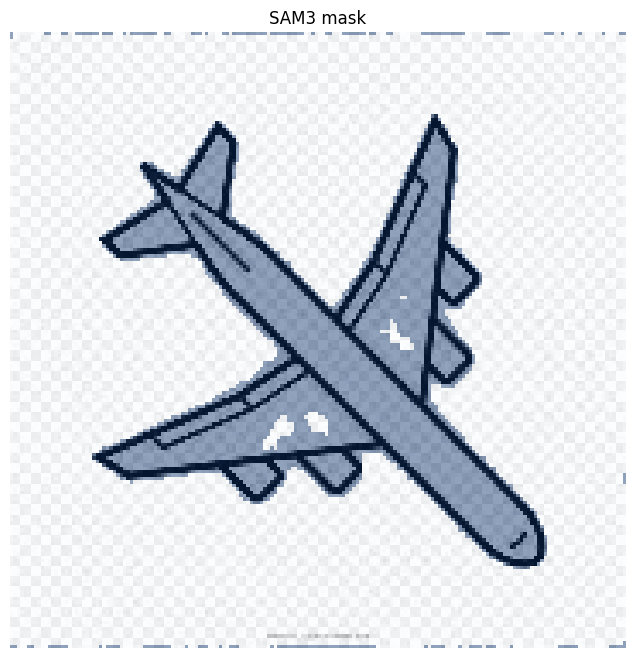

mask shape: (180, 180)


In [41]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

# 1. إعداد الموديل والمعالج
device = "cuda" if torch.cuda.is_available() else "cpu"

sam_model = build_sam3_image_model(bpe_path)
sam_model.to(device)
sam_model.eval()
sam_processor = Sam3Processor(sam_model)

# 2. تحميل الصورة وتوليد الـ State
image_path = "/content/th.webp"
image = Image.open(image_path).convert("RGB")
state = sam_processor.set_image(image)

# 3. إضافة المربع (final_box جاي من الخلية اللي فوق)
sam_processor.add_geometric_prompt(
    box=final_box,
    label=2,  # 2 تعني box
    state=state
)

# 4. استخراج الأقنعة من الـ state وعكسها
masks = state['masks']              # القناع على الخلفية
inverted_masks = ~masks             # القناع على الجسم نفسه

# 5. تحويل القناع إلى مصفوفة Numpy
if isinstance(inverted_masks, torch.Tensor):
    mask_np = inverted_masks.cpu().numpy().squeeze() # Added .squeeze() here
else:
    mask_np = np.array(inverted_masks).squeeze() # Added .squeeze() here

# 6. عرض سريع للتأكد
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.imshow(mask_np, alpha=0.45, cmap="Blues")
plt.title("SAM3 mask")
plt.axis("off")
plt.show()

print("mask shape:", mask_np.shape)

In [42]:
def bbox_from_mask(mask_np, pad_px=10):
    """يحسب bounding box حقيقي من قناع SAM (أدق من صندوق الـ CLIP)."""
    mask_2d = mask_np[0] if mask_np.ndim == 3 else mask_np
    mask_u8 = (mask_2d > 0).astype(np.uint8) * 255
    x, y, w, h = cv2.boundingRect(mask_u8)
    H, W = mask_2d.shape[:2]
    x1 = max(x - pad_px, 0)
    y1 = max(y - pad_px, 0)
    x2 = min(x + w + pad_px, W)
    y2 = min(y + h + pad_px, H)
    return [x1, y1, x2, y2]

In [43]:
import cv2

def build_trace_source_from_image(image: Image.Image, bbox=None, use_otsu=True, manual_thresh=None):
    """
    يبني مصفوفة ثنائية للتتبع من الصورة الأصلية (مش من قناع SAM)، عشان يحافظ
    على كل التفاصيل الداخلية (الحلقات/الفتحات) اللي SAM بيدمجها في قناع مليان
    واحد من غير أي holes.
    """
    gray = np.array(image.convert("L"))

    if bbox is not None:
        x1, y1, x2, y2 = [int(v) for v in bbox]
        crop = gray[y1:y2, x1:x2]
    else:
        crop = gray

    if use_otsu:
        _, ink = cv2.threshold(crop, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    else:
        _, ink = cv2.threshold(crop, manual_thresh, 255, cv2.THRESH_BINARY_INV)

    return ink  # ink = 255 حيث فيه خط، و0 في الخلفية

## Potrace: تحويل القناع لمسارات متجهية

`potracer` بياخد مصفوفة ثنائية (0/1) وبيرجع `Path` بيتكوّن من `Curve` واحد أو أكتر
(كونتور مغلق لكل شكل)، وكل `Curve` بيتكوّن من `Segment`s: إما **corner** (زاوية = خطين
مستقيمين) أو **bezier curve** (منحنى تكعيبي بنقطتين تحكم `c1`, `c2`). ده بيدّينا دقة
هندسية حقيقية بدل تتبّع بكسل-بـ-بكسل زي السكيلتون.

In [44]:
import potrace
import numpy as np

def mask_to_potrace_path(mask_np,
                          turdsize: int = 2,
                          alphamax: float = 1.0,
                          opticurve: bool = True,
                          opttolerance: float = 0.2):
    """
    يحوّل قناع ثنائي (binary mask) إلى مسار متجهي (potrace.Path) باستخدام خوارزمية Potrace.

    turdsize     : بيشيل أي كونتور مساحته أصغر من العدد ده (denoising / تنظيف الشوائب)
    alphamax     : حساسية تحويل الزوايا لمنحنيات ناعمة (0 = زوايا حادة فقط)
    opticurve    : تبسيط عدد أجزاء المنحنى (Bezier) الناتج
    opttolerance : أقصى خطأ مسموح به أثناء التبسيط
    """
    if mask_np.ndim == 3:
        mask_2d = mask_np[0]
    else:
        mask_2d = mask_np

    # ⚠️ ملحوظة مهمة عن مكتبة potracer (v0.0.4):
    # الكونستركتور بتاع Bitmap بيعمل self.invert() تلقائيًا جوه __init__ بعد الـ threshold.
    # لو بعتنا مصفوفة 0/1 عادية (زي (mask>0).astype(uint32))، كل القيم بتبقى أصغر من
    # عتبة الـ blacklevel (127.5)، فكل البكسلات بتتحسب "خلفية"، وبعد الـ invert التلقائي
    # كل الصورة بتتحول لـ "مقدمة" (foreground) واحدة متصلة = بيتتبّع حد الصورة كلها كـ
    # كونتور واحد بس، بغض النظر عن شكل القناع الحقيقي (وده بالظبط سبب مشكلة "كونتور واحد
    # بس" اللي كانت شغالة معانا قبل كده).
    # الحل: نبعت الصورة بصيغة uint8 في مدى 0-255 مع عكس القيم (الحبر = 0، الخلفية = 255)
    # عشان الـ invert() الداخلي يرجعها صح (الحبر = True/foreground فعليًا).
    binary_u8 = np.where(mask_2d > 0, 0, 255).astype(np.uint8)

    bmp = potrace.Bitmap(binary_u8)
    path = bmp.trace(
        turdsize=turdsize,
        turnpolicy=potrace.POTRACE_TURNPOLICY_MINORITY,
        alphamax=alphamax,
        opticurve=opticurve,
        opttolerance=opttolerance,
    )
    return path




def _pt(p):
    """يحوّل أي كائن نقطة (Point object بتاع potracer، أو tuple/list عادي) لصيغة (x, y) رقمية."""
    if hasattr(p, "x") and hasattr(p, "y"):
        return (float(p.x), float(p.y))
    return (float(p[0]), float(p[1]))


def cubic_bezier_points(p0, c1, c2, p1, steps=12):
    p0, c1, c2, p1 = _pt(p0), _pt(c1), _pt(c2), _pt(p1)
    ts = np.linspace(0.0, 1.0, steps)
    pts = []
    for t in ts:
        x = ((1 - t) ** 3 * p0[0] + 3 * (1 - t) ** 2 * t * c1[0]
             + 3 * (1 - t) * t ** 2 * c2[0] + t ** 3 * p1[0])
        y = ((1 - t) ** 3 * p0[1] + 3 * (1 - t) ** 2 * t * c1[1]
             + 3 * (1 - t) * t ** 2 * c2[1] + t ** 3 * p1[1])
        pts.append((x, y))
    return pts


def curve_to_polyline(curve, bezier_steps=12):
    pts = [_pt(curve.start_point)]
    for seg in curve:
        if seg.is_corner:
            pts.append(_pt(seg.c))
            pts.append(_pt(seg.end_point))
        else:
            start = pts[-1]
            flat = cubic_bezier_points(start, seg.c1, seg.c2, seg.end_point, bezier_steps)
            pts.extend(flat[1:])
    return pts

In [45]:
def apply_kerf_compensation(path_pts: np.ndarray,
                             tool_diameter_mm: float,
                             scale_mm_px: float,
                             is_internal: bool = True) -> np.ndarray:
    """تعويض قطر الريشة/الأداة (kerf) — بتزيح كل نقطة عن مركز الكونتور بمقدار نص قطر الأداة."""
    tool_radius_px = (tool_diameter_mm / 2.0) / scale_mm_px
    offset = -tool_radius_px if is_internal else +tool_radius_px

    pts = path_pts.astype(np.float64)
    cx = pts[:, 0].mean()
    cy = pts[:, 1].mean()

    result = []
    for x, y in pts:
        dx, dy = x - cx, y - cy
        dist = np.hypot(dx, dy)
        if dist < 1e-9:
            result.append([x, y])
        else:
            result.append([x + offset * dx / dist, y + offset * dy / dist])
    return np.array(result, dtype=np.float64)

In [46]:
import ezdxf


def build_dxf_from_potrace(
        mask_np: np.ndarray,
        params: dict,
        output_path: str = "output_cnc.dxf",
        entity_type: str = "lwpolyline",   # "lwpolyline" (خطوط منفردة) أو "spline" (منحنى ناعم لكل كونتور)
        apply_kerf: bool = True,
        is_internal: bool = True,
        bezier_steps: int = 12,
        turdsize: int = 2,
        alphamax: float = 1.0,
        opttolerance: float = 0.2,
):
    print("=" * 55)
    print("    🔧  CNC DXF Pipeline — Potrace Mode")
    print("=" * 55)

    if mask_np.ndim == 3:
        mask_2d = mask_np[0]
    else:
        mask_2d = mask_np
    img_h, img_w = mask_2d.shape[:2]

    # ══════════════════════════════════════════════════════════
    # STEP 1 — Potrace Vectorization
    # ══════════════════════════════════════════════════════════
    print("⏳ Step 1 — Potrace tracing ...")
    path = mask_to_potrace_path(
        mask_2d, turdsize=turdsize, alphamax=alphamax, opttolerance=opttolerance
    )
    curves = list(path)
    if len(curves) == 0:
        print("⚠️  Potrace متلاقاش أي كونتور في القناع ده.")
        return None
    print(f"   عدد الكونتورات (Curves): {len(curves)}")

    # كل كونتور بيتحول لقائمة نقاط (px)، ونجمعهم كلهم عشان نحسب bounding box شامل
    polylines_px = [np.array(curve_to_polyline(c, bezier_steps)) for c in curves]
    all_pts = np.vstack(polylines_px)

    x_min, y_min = all_pts[:, 0].min(), all_pts[:, 1].min()
    x_max, y_max = all_pts[:, 0].max(), all_pts[:, 1].max()
    w_b = max(x_max - x_min, 1)
    h_b = max(y_max - y_min, 1)

    scale = min(
        params["part_width_mm"] / w_b,
        params["part_height_mm"] / h_b,
    )
    margin = params.get("margin_mm", 10)

    print(f"\n📐 Scale        : {scale:.5f} mm/px")
    print(f"📦 Part size    : {w_b*scale:.1f} × {h_b*scale:.1f} mm")
    print(f"🔩 Tool diameter: {params['tool_diameter_mm']} mm")
    print(f"🧵 عدد الكونتورات: {len(polylines_px)}\n")

    # ══════════════════════════════════════════════════════════
    # STEP 2 — (اختياري) تعويض قطر الأداة (Kerf)
    # ══════════════════════════════════════════════════════════
    if apply_kerf:
        print("⏳ Step 2 — Kerf compensation ...")
        polylines_px = [
            apply_kerf_compensation(
                pl, params["tool_diameter_mm"], scale, is_internal=is_internal
            )
            for pl in polylines_px
        ]

    # ══════════════════════════════════════════════════════════
    # STEP 3 — بناء ملف الـ DXF
    # ══════════════════════════════════════════════════════════
    print("⏳ Step 3 — Building DXF ...")
    doc = ezdxf.new(dxfversion="R2010")
    doc.units = ezdxf.units.MM
    if "CUT" not in doc.layers:
        doc.layers.add(name="CUT", color=1)
    msp = doc.modelspace()

    def px_to_mm(pt):
        x_mm = (pt[0] - x_min) * scale + margin
        y_mm = (y_max - pt[1]) * scale + margin   # نعكس محور y (نظام الصورة معكوس رأسيًا)
        return (x_mm, y_mm)

    for pl in polylines_px:
        pts_mm = [px_to_mm(p) for p in pl]
        if len(pts_mm) < 2:
            continue
        if entity_type == "spline":
            msp.add_spline(fit_points=pts_mm, dxfattribs={"layer": "CUT"})
        else:
            msp.add_lwpolyline(pts_mm, close=True, dxfattribs={"layer": "CUT"})

    doc.saveas(output_path)
    print(f"\n✅ تم حفظ الملف: {output_path}")
    return doc

In [47]:
machine_params = {
    # ── أبعاد القطعة الحقيقية ──────────────────────────────
    "part_width_mm":    700.0,
    "part_height_mm":   700.0,

    # ── الريشة ─────────────────────────────────────────────
    "tool_diameter_mm": 5.0,

    # ── اللوح ──────────────────────────────────────────────
    "sheet_width_mm":   1000.0,
    "sheet_height_mm":  1000.0,

    # ── هامش ─────────────────────────────────────────────
    "margin_mm":        10.0,
}

In [48]:
if __name__ == "__main__":
    print("\n🧪 Running Potrace → DXF pipeline ...\n")

    real_box = bbox_from_mask(mask_np, pad_px=10)   # ← بدل final_box
    print("Bounding box المستخدم:", real_box)

    trace_source = build_trace_source_from_image(image, bbox=real_box)

    doc = build_dxf_from_potrace(
        mask_np       = trace_source,
        params        = machine_params,
        output_path   = "test_output.dxf",
        entity_type   = "lwpolyline",
        apply_kerf    = True,
        is_internal   = True,
        bezier_steps  = 12,
        turdsize      = 2,
        alphamax      = 1.0,
        opttolerance  = 0.2,
    )

    if doc:
        msp = doc.modelspace()
        entities = list(msp)
        print(f"\n✅ DXF entities in modelspace: {len(entities)}")
        print("Test passed!")


🧪 Running Potrace → DXF pipeline ...

Bounding box المستخدم: [0, 0, 180, 180]
    🔧  CNC DXF Pipeline — Potrace Mode
⏳ Step 1 — Potrace tracing ...
   عدد الكونتورات (Curves): 16

📐 Scale        : 5.29007 mm/px
📦 Part size    : 694.3 × 700.0 mm
🔩 Tool diameter: 5.0 mm
🧵 عدد الكونتورات: 16

⏳ Step 2 — Kerf compensation ...
⏳ Step 3 — Building DXF ...

✅ تم حفظ الملف: test_output.dxf

✅ DXF entities in modelspace: 16
Test passed!


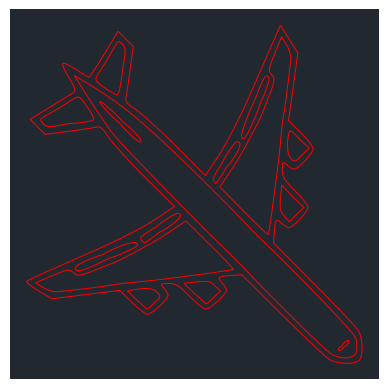

✅ Preview saved!


In [49]:
import ezdxf
import matplotlib.pyplot as plt
from ezdxf.addons.drawing import RenderContext, Frontend
from ezdxf.addons.drawing.matplotlib import MatplotlibBackend

doc = ezdxf.readfile('test_output.dxf')
msp = doc.modelspace()

fig, ax = plt.subplots(figsize=(10, 10))
ctx = RenderContext(doc)
backend = MatplotlibBackend(ax)
Frontend(ctx, backend).draw_layout(msp)

ax.set_aspect('equal')
plt.savefig('dxf_preview.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Preview saved!")